In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('india_cancer_patients_2022_2025.csv')

In [3]:
df.head()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
0,IND-CAN-100000,82,Female,Delhi,New Delhi,Rajiv Gandhi Cancer Institute,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased
1,IND-CAN-100001,45,Female,West Bengal,Kolkata,Tata Medical Center,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive
2,IND-CAN-100002,47,Male,Chandigarh,Chandigarh,PGIMER,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive
3,IND-CAN-100003,1,Female,Delhi,New Delhi,AIIMS,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive
4,IND-CAN-100004,52,Female,Maharashtra,Mumbai,Tata Memorial Hospital,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased


# EDA

In [4]:
df.shape

(100000, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Patient_ID       100000 non-null  object 
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   State            100000 non-null  object 
 4   City             100000 non-null  object 
 5   Hospital_Name    100000 non-null  object 
 6   Cancer_Type      100000 non-null  object 
 7   Stage            100000 non-null  object 
 8   Treatment_Type   100000 non-null  object 
 9   Diagnosis_Date   100000 non-null  object 
 10  Survival_Months  100000 non-null  float64
 11  Status           100000 non-null  object 
dtypes: float64(1), int64(1), object(10)
memory usage: 9.2+ MB


In [6]:
df.describe()

,Age,Survival_Months
count,100000.000000,100000.000000
mean,53.899460,20.333353
std,13.653781,14.156450
min,1.000000,1.000000
25%,45.000000,8.200000
50%,54.000000,17.200000
75%,63.000000,30.600000
max,95.000000,53.300000


In [7]:
df.isna().sum()

Patient_ID         0
Age                0
Gender             0
State              0
City               0
Hospital_Name      0
Cancer_Type        0
Stage              0
Treatment_Type     0
Diagnosis_Date     0
Survival_Months    0
Status             0
dtype: int64

In [8]:
df.duplicated().value_counts()

False    100000
Name: count, dtype: int64

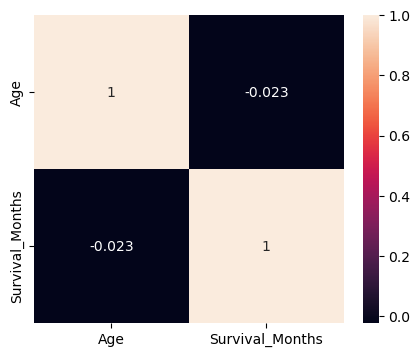

In [9]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [10]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'State', 'City', 'Hospital_Name',
       'Cancer_Type', 'Stage', 'Treatment_Type', 'Diagnosis_Date',
       'Survival_Months', 'Status'],
      dtype='object')

In [11]:
for col in ['Gender', 'Cancer_Type', 'Stage', 'Treatment_Type', 'Status']:
    print(f"--- Value Counts for {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Value Counts for Gender ---
Gender
Female    67151
Male      32849
Name: count, dtype: int64


--- Value Counts for Cancer_Type ---
Cancer_Type
Breast Cancer        28169
Oral Cancer          16259
Cervical Cancer      13881
Lung Cancer          12046
Colorectal Cancer     7935
Stomach Cancer        7923
Prostate Cancer       5809
Leukemia              4070
Ovarian Cancer        3908
Name: count, dtype: int64


--- Value Counts for Stage ---
Stage
Stage III    35261
Stage II     24915
Stage IV     24768
Stage I      15056
Name: count, dtype: int64


--- Value Counts for Treatment_Type ---
Treatment_Type
Palliative Care           21102
Surgery                   20635
Chemotherapy              16046
Targeted Therapy          13519
Radiation                 11618
Chemo + Radiation          8547
Surgery + Chemotherapy     8533
Name: count, dtype: int64


--- Value Counts for Status ---
Status
Deceased    63577
Alive       36423
Name: count, dtype: int64




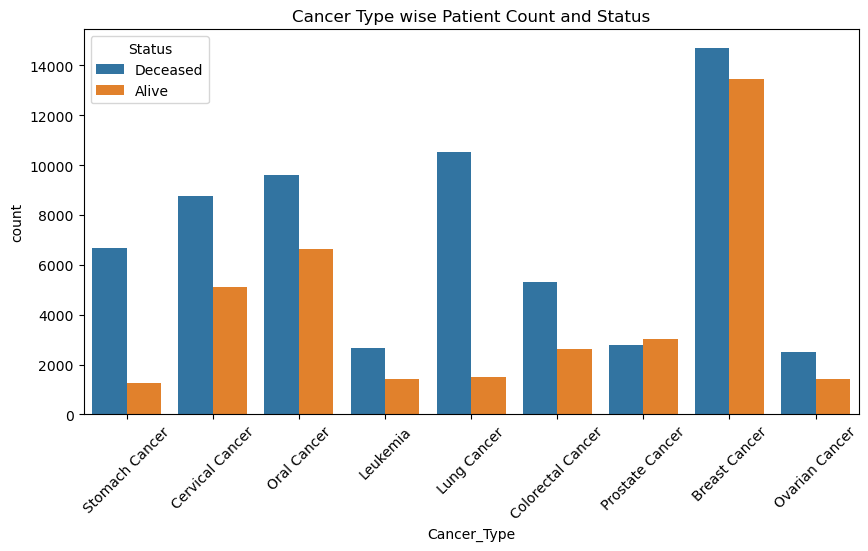

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Cancer_Type', hue='Status')
plt.title('Cancer Type wise Patient Count and Status')
plt.xticks(rotation=45)
plt.show()

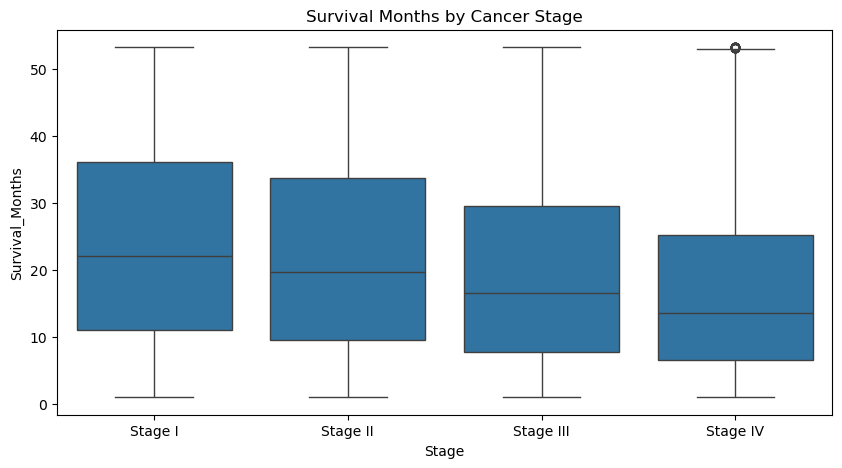

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Stage', y='Survival_Months', order=['Stage I', 'Stage II', 'Stage III', 'Stage IV'])
plt.title('Survival Months by Cancer Stage')
plt.show()

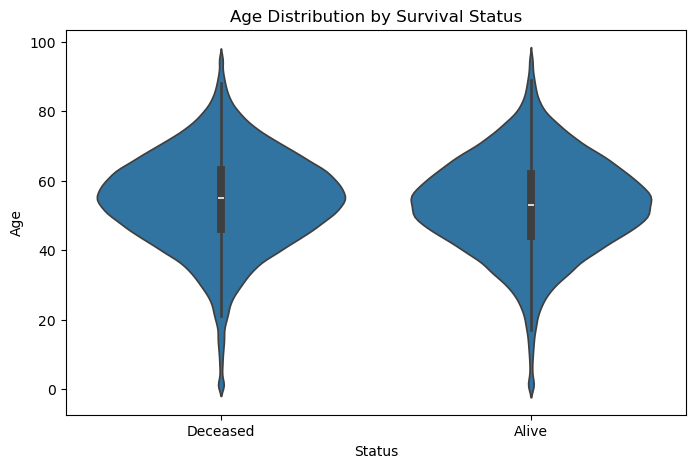

In [14]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Status', y='Age')
plt.title('Age Distribution by Survival Status')
plt.show()

# EDA Analysis

## Dataset Overview

* Data Dimensions: The dataset is robust, consisting of 100,000 (1 Lac) rows and 12 columns.
* Data Quality: The data is perfectly clean; there are no missing (null) values and no duplicated rows.
* Feature Types: The dataset is heavily categorical, containing only two numeric features (Age and Survival_Months).
* Correlation: A weak inverse correlation exists between the numeric features, indicating that age alone isn't a dominant driving factor for survival duration.

## Key Insights & Cancer Type Trends

* Gender & Prevalence: Survival numbers lean higher for female patients, primarily driven by the high volume of Breast Cancer cases.
* Volume vs. Mortality: * Breast Cancer registers both the highest number of survivors (Alive) and the highest absolute number of fatalities (Deceased), due to its high overall prevalence in the data
* Oral Cancer follows as the second highest in terms of patient survival.
* Lethality (High Mortality Rate): Stomach Cancer and Lung Cancer emerge as the most lethal types, showing significantly lower survival rates relative to their total case counts.

## Survival Duration by Stage (Crucial Trend)

* Stage I: Highest average survival duration, ranging between 20–23 months.
* Stage II: A slight decrease, dropping to 20–21 months.
* Stage III: Shows further progression of the disease with survival dropping to 17–19 months.
* Stage IV: The most critical stage, where average survival drops sharply to 12–13 months.

# Data Cleaning and preprocessing

In [15]:
df_cleaned = df.copy()

In [16]:
df.tail()

,Patient_ID,Age,Gender,State,City,Hospital_Name,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status
99995,IND-CAN-199995,50,Female,Delhi,New Delhi,AIIMS,Breast Cancer,Stage III,Surgery + Chemotherapy,2023-12-03,17.7,Deceased
99996,IND-CAN-199996,32,Female,Karnataka,Bengaluru,Kidwai Memorial Institute of Oncology,Breast Cancer,Stage IV,Targeted Therapy,2025-04-12,6.3,Deceased
99997,IND-CAN-199997,92,Female,West Bengal,Kolkata,Tata Medical Center,Stomach Cancer,Stage II,Radiation,2024-09-06,21.1,Alive
99998,IND-CAN-199998,60,Female,Tamil Nadu,Chennai,Adyar Cancer Institute,Breast Cancer,Stage II,Palliative Care,2023-06-04,32.4,Deceased
99999,IND-CAN-199999,69,Female,Chandigarh,Chandigarh,PGIMER,Cervical Cancer,Stage IV,Palliative Care,2025-06-08,1.5,Deceased


In [17]:
columns_to_drop = ['Patient_ID', 'State', 'City', 'Hospital_Name']
df_cleaned.drop(columns=columns_to_drop, axis=1, inplace=True)

In [18]:
df_cleaned['Diagnosis_Date'] = pd.to_datetime(df_cleaned['Diagnosis_Date'])

In [19]:
df_cleaned['Diagnosis_Year'] = df_cleaned['Diagnosis_Date'].dt.year

In [20]:
df_cleaned.head()

,Age,Gender,Cancer_Type,Stage,Treatment_Type,Diagnosis_Date,Survival_Months,Status,Diagnosis_Year
0,82,Female,Stomach Cancer,Stage III,Palliative Care,2024-06-05,3.5,Deceased,2024
1,45,Female,Cervical Cancer,Stage IV,Palliative Care,2023-08-12,34.0,Alive,2023
2,47,Male,Oral Cancer,Stage III,Targeted Therapy,2023-09-09,33.0,Alive,2023
3,1,Female,Leukemia,Stage II,Palliative Care,2024-03-01,27.3,Alive,2024
4,52,Female,Cervical Cancer,Stage IV,Palliative Care,2022-05-17,24.0,Deceased,2022


In [21]:
df_cleaned.drop('Diagnosis_Date', axis=1, inplace=True)

In [22]:
Encoding_columns = ['Cancer_Type', 'Stage', 'Treatment_Type']
df_cleaned = pd.get_dummies(
    data=df_cleaned,
    columns=Encoding_columns, 
    drop_first=True, 
    dtype=int
)

In [23]:
df_cleaned.tail()

,Age,Gender,Survival_Months,Status,Diagnosis_Year,Cancer_Type_Cervical Cancer,Cancer_Type_Colorectal Cancer,Cancer_Type_Leukemia,Cancer_Type_Lung Cancer,Cancer_Type_Oral Cancer,...,Cancer_Type_Stomach Cancer,Stage_Stage II,Stage_Stage III,Stage_Stage IV,Treatment_Type_Chemotherapy,Treatment_Type_Palliative Care,Treatment_Type_Radiation,Treatment_Type_Surgery,Treatment_Type_Surgery + Chemotherapy,Treatment_Type_Targeted Therapy
99995,50,Female,17.7,Deceased,2023,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
99996,32,Female,6.3,Deceased,2025,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
99997,92,Female,21.1,Alive,2024,0,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
99998,60,Female,32.4,Deceased,2023,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
99999,69,Female,1.5,Deceased,2025,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [24]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_status = LabelEncoder()

df_cleaned['Gender'] = le_gender.fit_transform(df_cleaned['Gender'].astype(str))
df_cleaned['Status'] = le_status.fit_transform(df_cleaned['Status'].astype(str))

df_cleaned[['Gender', 'Status']].tail()

,Gender,Status
99995,0,1
99996,0,1
99997,0,0
99998,0,1
99999,0,1


In [25]:
df_cleaned.tail()

# in Gender column 0 represents women and in Status column 1 represents deceased

,Age,Gender,Survival_Months,Status,Diagnosis_Year,Cancer_Type_Cervical Cancer,Cancer_Type_Colorectal Cancer,Cancer_Type_Leukemia,Cancer_Type_Lung Cancer,Cancer_Type_Oral Cancer,...,Cancer_Type_Stomach Cancer,Stage_Stage II,Stage_Stage III,Stage_Stage IV,Treatment_Type_Chemotherapy,Treatment_Type_Palliative Care,Treatment_Type_Radiation,Treatment_Type_Surgery,Treatment_Type_Surgery + Chemotherapy,Treatment_Type_Targeted Therapy
99995,50,0,17.7,1,2023,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
99996,32,0,6.3,1,2025,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
99997,92,0,21.1,0,2024,0,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
99998,60,0,32.4,1,2023,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
99999,69,0,1.5,1,2025,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['Age', 'Survival_Months', 'Diagnosis_Year']

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [27]:
X = df_cleaned.drop(['Survival_Months', 'Status'], axis=1)
y = df_cleaned['Status']

# Training Model to find status(Deceased/Alive)

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, f1_score

In [29]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [30]:
from xgboost import XGBClassifier

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
classifer_svm = SVC()
classifer_tree = DecisionTreeClassifier()
classifer_KNN = KNeighborsClassifier()
classifer_LG = LogisticRegression()
classifer_NB = GaussianNB()
classifer_RF = RandomForestClassifier()
classifer_GB = GradientBoostingClassifier()
classifer_Ada = AdaBoostClassifier()

In [33]:
results_classifier = []
n = X_test.shape[0]
k = X_test.shape[1] 

models_classifier = {
    # 'SVC': SVC(), 
    'Decision Tree': DecisionTreeClassifier(), 
    # 'KNN': KNeighborsClassifier(),  
    'Logistic': LogisticRegression(), 
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(), 
    'Gradient Boosting': GradientBoostingClassifier(), 
    'AdaBoost': AdaBoostClassifier(),
    'XG Boost': XGBClassifier()
}

In [34]:
for name,model in models_classifier.items():
    model.fit(X_train, y_train)
    y_pred_classifier = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_classifier)
    f1  = f1_score(y_test, y_pred_classifier)
    # adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    results_classifier.append({
        'name': name, 
        'accuracy_score': acc, 
        'f1_score': f1, 
    })

In [35]:
# Had to terminate SVM and KNN because of their slow execution
results_classifier

[{'name': 'Decision Tree',
  'accuracy_score': 0.6447878787878788,
  'f1_score': 0.7113234497364922},
 {'name': 'Logistic',
  'accuracy_score': 0.7244545454545455,
  'f1_score': 0.7965999328934124},
 {'name': 'Naive Bayes',
  'accuracy_score': 0.6730909090909091,
  'f1_score': 0.7141797371767699},
 {'name': 'Random Forest',
  'accuracy_score': 0.6645454545454546,
  'f1_score': 0.7410162829870859},
 {'name': 'Gradient Boosting',
  'accuracy_score': 0.7255151515151516,
  'f1_score': 0.7953734242985587},
 {'name': 'AdaBoost',
  'accuracy_score': 0.7251515151515151,
  'f1_score': 0.792666758103598},
 {'name': 'XG Boost',
  'accuracy_score': 0.719030303030303,
  'f1_score': 0.7923218205438337}]

In [36]:
classifer_GB.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
y_pred = classifer_GB.predict(X_test) 
print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred))

0.7255151515151516
0.7953734242985587


# Important Features

In [38]:
importances = classifer_GB.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

In [39]:
feature_imp_df.head(10)

,Feature,Importance
13,Stage_Stage IV,0.364949
6,Cancer_Type_Lung Cancer,0.209947
12,Stage_Stage III,0.204289
10,Cancer_Type_Stomach Cancer,0.100548
11,Stage_Stage II,0.029933
17,Treatment_Type_Surgery,0.024734
9,Cancer_Type_Prostate Cancer,0.012877
4,Cancer_Type_Colorectal Cancer,0.012728
3,Cancer_Type_Cervical Cancer,0.011524
8,Cancer_Type_Ovarian Cancer,0.005363


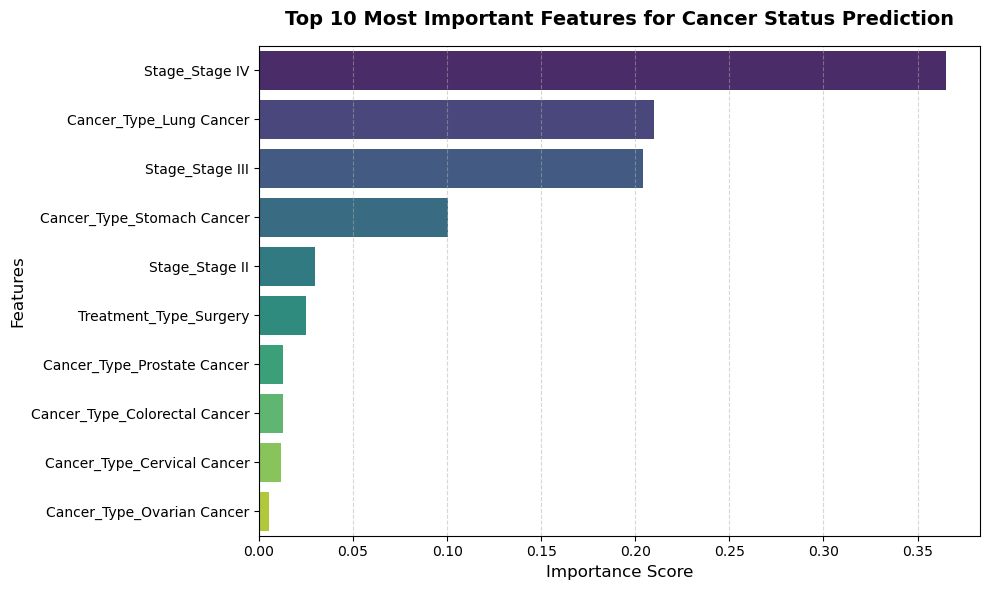

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis') 

plt.title('Top 10 Most Important Features for Cancer Status Prediction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12) 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Feature Importance Insights:
1. **Dominance of Stage IV & Lung Cancer:** 'Stage_Stage IV' emerges as the single most critical feature with an importance score of 0.36, closely followed by 'Cancer_Type_Lung Cancer' (0.21). This indicates that advanced stages and specific high-risk cancer types heavily influence the model's prediction of patient status.
2. **Impact of Cancer Progression:** Three out of the top five features are related to the cancer stage (Stage IV, Stage III, and Stage II). This highlights that the clinical progression of the disease at the time of diagnosis is the most decisive factor in predicting outcomes.
3. **Key Cancer Types:** Among all cancer types, Lung Cancer and Stomach Cancer hold the highest predictive power, whereas Ovarian and Cervical cancers show relatively lower importance scores in this dataset.
4. **Treatment Significance:** 'Treatment_Type_Surgery' is the only treatment modality that made it to the top features, suggesting that surgical intervention carries more weight in the classification process compared to other treatments.